# UK Road Accidents Analysis

EDA, association rule mining, regional clustering, and time series forecasting on UK road accident data (2021-2022).

## Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from IPython.display import display
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

## Data Loading and Cleaning

In [5]:
df = pd.read_csv("Road Accident Data.csv")

# Use format='mixed' to handle both slash and dash date formats
df['Accident Date'] = pd.to_datetime(df['Accident Date'], format='mixed', dayfirst=True)
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour
df['Month'] = df['Accident Date'].dt.month
df['Year'] = df['Accident Date'].dt.year

# Replace placeholder junk with actual NaN
df.replace('Data missing or out of range', np.nan, inplace=True)

print(df.isna().sum().sort_values(ascending=False).head(10))
print(df.shape)
print(df['Accident Date'].min(), "to", df['Accident Date'].max())

Carriageway_Hazards    302549
Junction_Control        98056
Time                       17
Hour                       17
Junction_Detail             0
Accident_Index              0
Accident Date               0
Day_of_Week                 0
Light_Conditions            0
Latitude                    0
dtype: int64
(307973, 24)
2021-01-01 00:00:00 to 2022-12-31 00:00:00


## EDA: Time of Day, Lighting, and Junctions

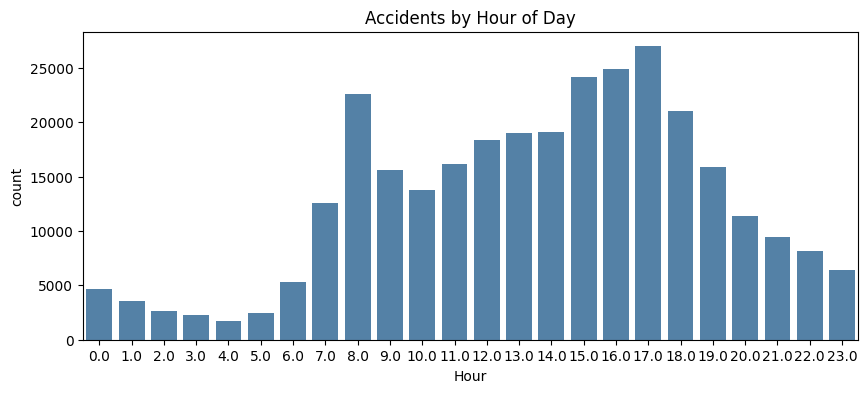

In [7]:
# Accidents by hour
plt.figure(figsize=(10,4))
sns.countplot(x='Hour', data=df, color='steelblue')
plt.title("Accidents by Hour of Day")
plt.show()

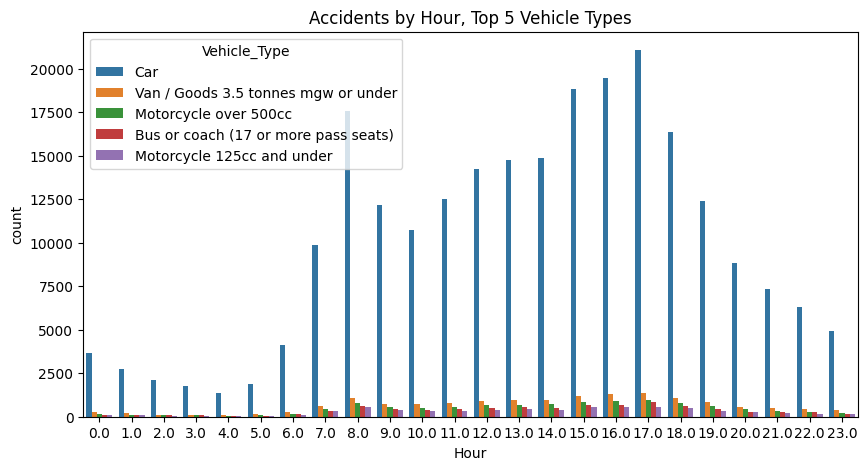

In [8]:
# Accidents by hour, split by vehicle type (top 5 vehicle types only, keeps it readable)
top_vehicles = df['Vehicle_Type'].value_counts().head(5).index
sub = df[df['Vehicle_Type'].isin(top_vehicles)]
plt.figure(figsize=(10,5))
sns.countplot(x='Hour', hue='Vehicle_Type', data=sub)
plt.title("Accidents by Hour, Top 5 Vehicle Types")
plt.show()

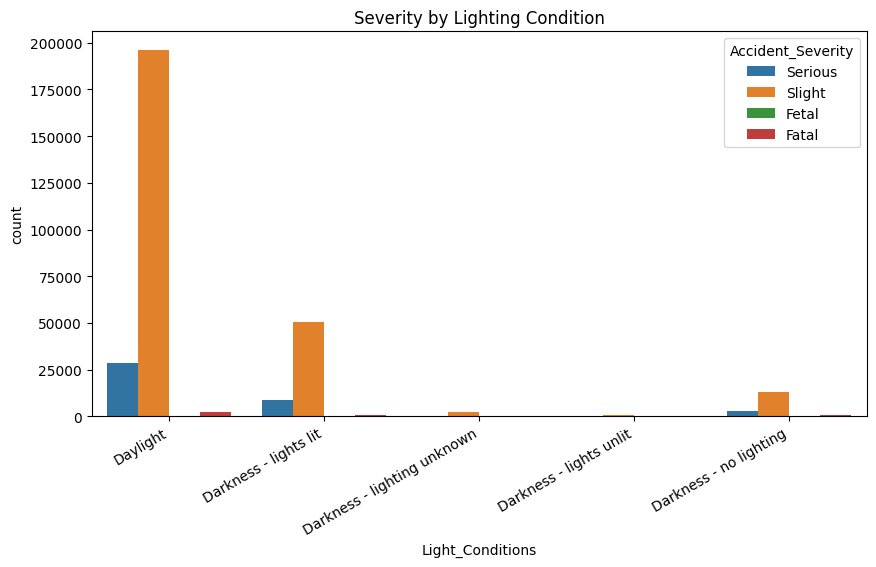

In [9]:
# Severity by lighting condition
plt.figure(figsize=(10,5))
sns.countplot(x='Light_Conditions', hue='Accident_Severity', data=df)
plt.xticks(rotation=30, ha='right')
plt.title("Severity by Lighting Condition")
plt.show()

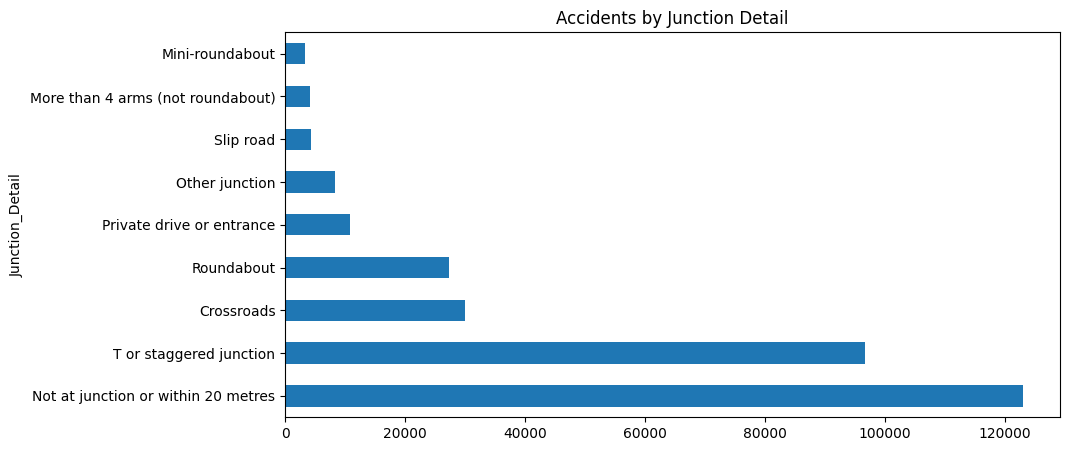

In [10]:
# Junction detail — accident counts
plt.figure(figsize=(10,5))
df['Junction_Detail'].value_counts().plot(kind='barh')
plt.title("Accidents by Junction Detail")
plt.show()

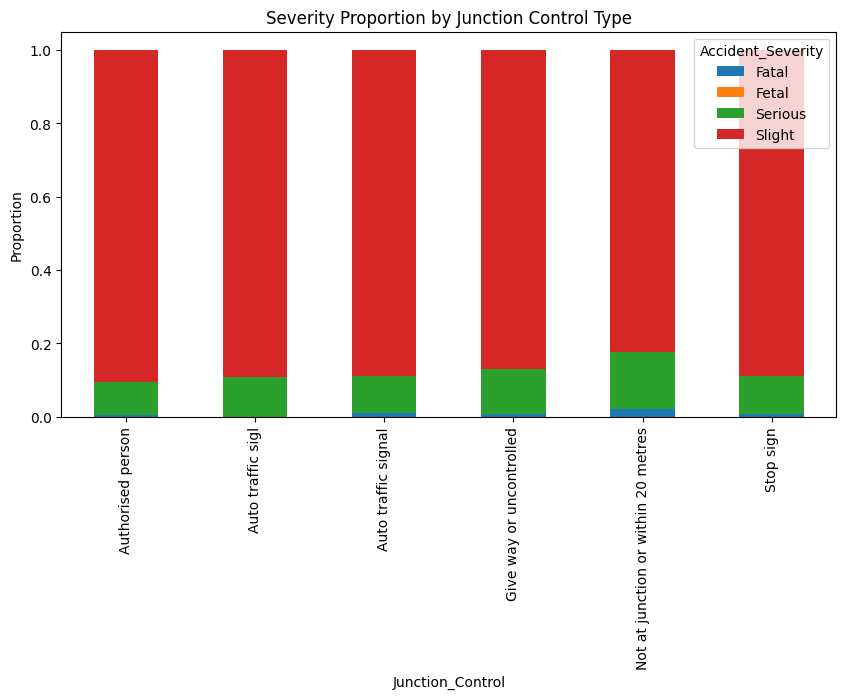

In [11]:
# Junction control vs severity
pd.crosstab(df['Junction_Control'], df['Accident_Severity'], normalize='index').plot(
    kind='bar', stacked=True, figsize=(10,5))
plt.title("Severity Proportion by Junction Control Type")
plt.ylabel("Proportion")
plt.show()

## Association Rule Mining (Apriori)

Cross-variable questions — does bad weather, darkness, or certain junction controls co-occur with higher severity?

In [13]:
# Build a "daylight vs darkness" flag to simplify lighting
df['Light_Simple'] = df['Light_Conditions'].apply(
    lambda x: 'Darkness' if isinstance(x, str) and 'Darkness' in x else 'Daylight')

apriori_cols = ['Weather_Conditions', 'Light_Simple', 'Road_Surface_Conditions',
                'Junction_Control', 'Accident_Severity']
basket_df = df[apriori_cols].dropna()

# One-hot encode
basket_encoded = pd.get_dummies(basket_df)

# Mine frequent itemsets
frequent_itemsets = apriori(basket_encoded, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

# Filter to rules that predict severity
severity_rules = rules[rules['consequents'].astype(str).str.contains('Accident_Severity')]
severity_rules = severity_rules.sort_values('lift', ascending=False)

# Clean up for display — convert frozensets to plain readable strings
table = severity_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).copy()
table['antecedents'] = table['antecedents'].apply(lambda x: ', '.join(list(x)))
table['consequents'] = table['consequents'].apply(lambda x: ', '.join(list(x)))
table[['support', 'confidence', 'lift']] = table[['support', 'confidence', 'lift']].round(3)
table.reset_index(drop=True, inplace=True)

display(table)

,antecedents,consequents,support,confidence,lift
0,"Junction_Control_Auto traffic signal, Road_Sur...","Accident_Severity_Slight, Weather_Conditions_R...",0.016,0.415,3.841
1,Weather_Conditions_Raining no high winds,"Junction_Control_Auto traffic signal, Accident...",0.016,0.128,3.799
2,"Junction_Control_Auto traffic signal, Weather_...","Accident_Severity_Slight, Road_Surface_Conditi...",0.016,0.835,3.652
3,"Light_Simple_Daylight, Road_Surface_Conditions...","Accident_Severity_Slight, Weather_Conditions_R...",0.045,0.281,3.645
4,"Weather_Conditions_Raining no high winds, Junc...","Light_Simple_Daylight, Accident_Severity_Sligh...",0.045,0.518,3.645
5,"Light_Simple_Daylight, Weather_Conditions_Rain...","Accident_Severity_Slight, Road_Surface_Conditi...",0.045,0.593,3.642
6,"Light_Simple_Daylight, Road_Surface_Conditions...","Accident_Severity_Slight, Weather_Conditions_R...",0.045,0.391,3.625
7,Road_Surface_Conditions_Wet or damp,"Weather_Conditions_Raining no high winds, Acci...",0.012,0.046,3.616
8,Road_Surface_Conditions_Wet or damp,"Light_Simple_Darkness, Accident_Severity_Sligh...",0.026,0.100,3.611
9,Road_Surface_Conditions_Wet or damp,"Light_Simple_Darkness, Accident_Severity_Sligh...",0.037,0.143,3.608


## Forecasting

Monthly accident volume trend, 2021-2022.

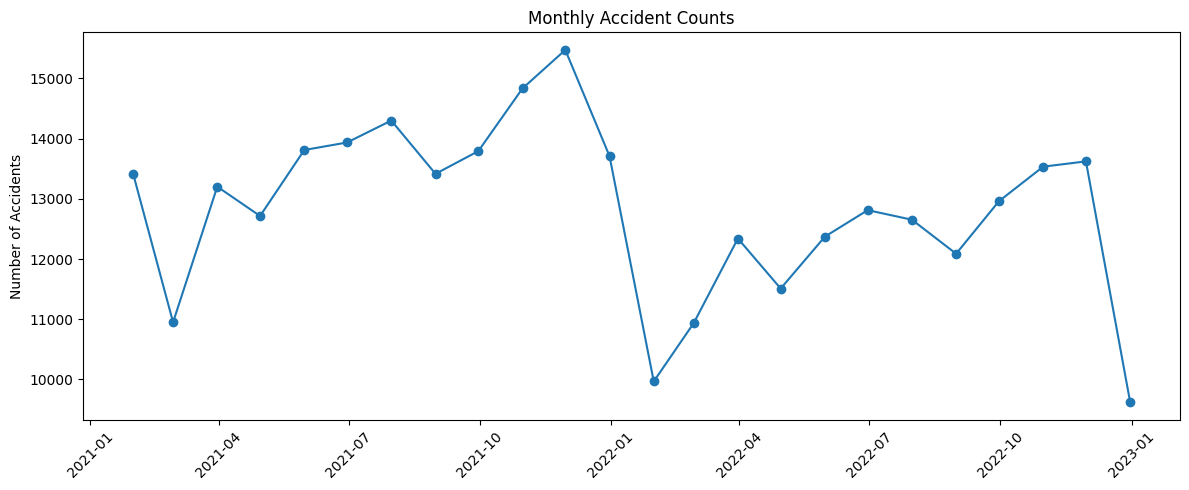

In [15]:
# Aggregate accidents by month
monthly = df.set_index('Accident Date').resample('M').size()
monthly = monthly.reset_index()
monthly.columns = ['Date', 'Accident_Count']

plt.figure(figsize=(12,5))
plt.plot(monthly['Date'], monthly['Accident_Count'], marker='o')
plt.title("Monthly Accident Counts")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

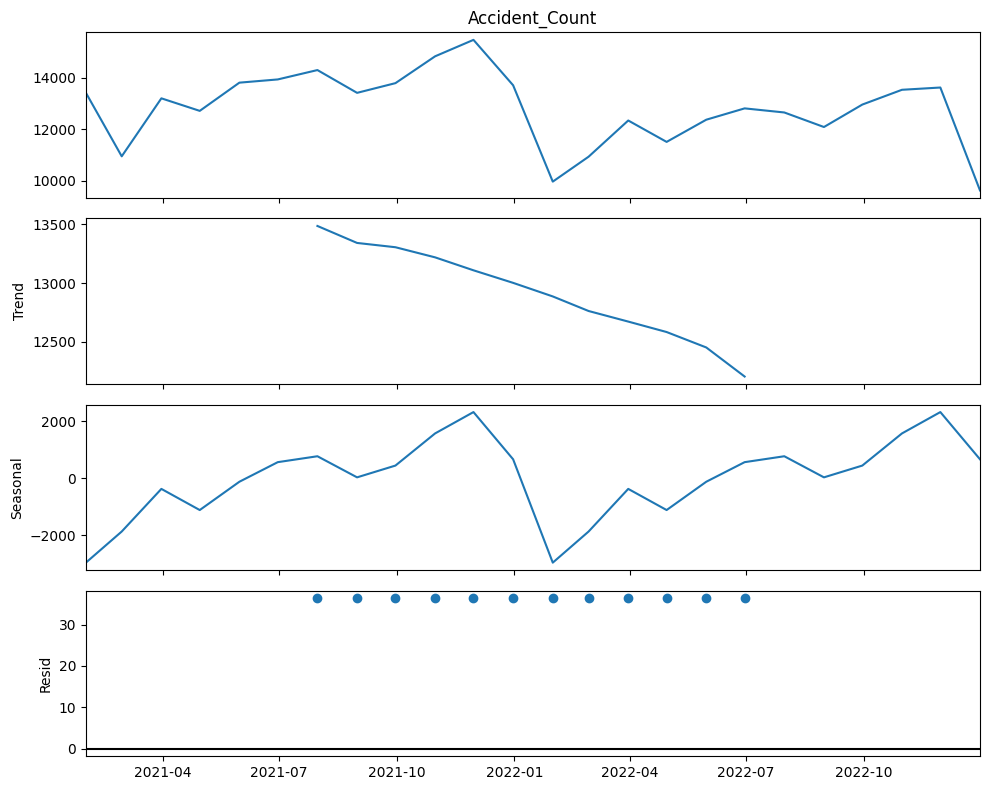

In [16]:
monthly_indexed = monthly.set_index('Date')['Accident_Count']

decomposition = seasonal_decompose(monthly_indexed, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

**Note:** with only 24 monthly observations, a full seasonal SARIMA model produced non-significant coefficients and a singular covariance matrix — not reliable. Kept below to show the reasoning, then replaced with a simpler trend-only model.

In [18]:
# Seasonal model attempt — unstable given limited data, shown for transparency
model = SARIMAX(monthly_indexed, order=(1,1,1), seasonal_order=(1,1,1,12))
results = model.fit(disp=False)
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                     Accident_Count   No. Observations:                   24
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -81.858
Date:                            Thu, 20 Aug 2026   AIC                            173.716
Time:                                    12:48:51   BIC                            175.705
Sample:                                01-31-2021   HQIC                           172.461
                                     - 12-31-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2094      0.421     -0.497      0.619      -1.034       0.616
ma.L1         -0.6479      0.392   

**Forecasting note:** A seasonal SARIMA model was unstable given only 24 months of data (non-significant coefficients, singular covariance matrix). A simplified trend-only ARIMA(1,1,1) model below showed statistically significant autocorrelation structure (p < 0.001), but numerical diagnostics (condition number, residual normality) suggest the fit should be treated as indicative rather than precise. Forecasts are shown with confidence intervals to reflect this uncertainty — a longer historical window would materially improve reliability.

                               SARIMAX Results                                
Dep. Variable:         Accident_Count   No. Observations:                   24
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -200.897
Date:                Thu, 20 Aug 2026   AIC                            407.795
Time:                        12:48:52   BIC                            411.201
Sample:                    01-31-2021   HQIC                           408.652
                         - 12-31-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8697      0.152      5.717      0.000       0.572       1.168
ma.L1         -0.9989      0.277     -3.608      0.000      -1.542      -0.456
sigma2      2.116e+06   1.29e-07   1.65e+13      0.0

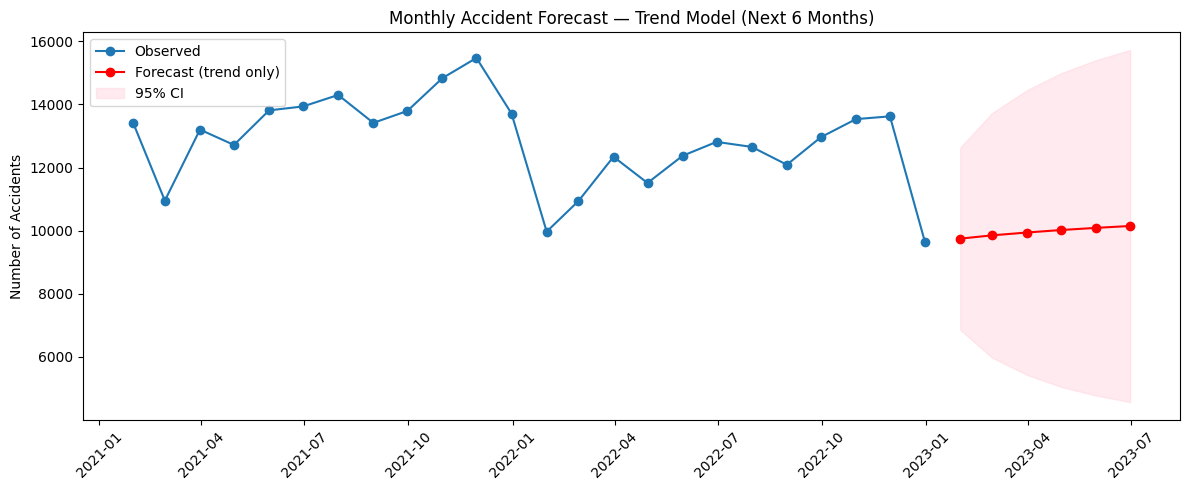

            Forecast  Lower_CI  Upper_CI
2023-01-31    9745.0    6858.0   12632.0
2023-02-28    9849.0    5974.0   13723.0
2023-03-31    9939.0    5425.0   14454.0
2023-04-30   10018.0    5045.0   14991.0
2023-05-31   10087.0    4770.0   15403.0
2023-06-30   10146.0    4565.0   15727.0


In [20]:
# Final model: trend-only ARIMA
model_simple = SARIMAX(monthly_indexed, order=(1,1,1))
results_simple = model_simple.fit(disp=False)
print(results_simple.summary())

forecast = results_simple.get_forecast(steps=6)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(12,5))
plt.plot(monthly_indexed.index, monthly_indexed, label='Observed', marker='o')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast (trend only)', color='red', marker='o')
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3, label='95% CI')
plt.title("Monthly Accident Forecast — Trend Model (Next 6 Months)")
plt.ylabel("Number of Accidents")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(pd.DataFrame({
    'Forecast': forecast_mean.round(0),
    'Lower_CI': conf_int.iloc[:,0].round(0),
    'Upper_CI': conf_int.iloc[:,1].round(0)
}))

## Regional Clustering

Grouping UK districts by accident profile.

In [22]:
# Aggregate key features by district
cluster_df = df.groupby('Local_Authority_(District)').agg(
    Total_Accidents=('Accident_Index', 'count'),
    Avg_Casualties=('Number_of_Casualties', 'mean'),
    Avg_Vehicles=('Number_of_Vehicles', 'mean'),
    Pct_Serious_Fatal=('Accident_Severity', lambda x: (x.isin(['Serious', 'Fatal'])).mean()),
    Pct_Urban=('Urban_or_Rural_Area', lambda x: (x == 'Urban').mean())
).reset_index()

print(cluster_df.shape)
cluster_df.head()

(422, 6)


,Local_Authority_(District),Total_Accidents,Avg_Casualties,Avg_Vehicles,Pct_Serious_Fatal,Pct_Urban
0,Aberdeen City,445,1.121348,1.640449,0.168539,0.826966
1,Aberdeenshire,687,1.318777,1.580786,0.298399,0.064047
2,Adur,284,1.299296,1.992958,0.193662,0.700704
3,Allerdale,524,1.503817,1.759542,0.139313,0.194656
4,Alnwick,20,1.550000,1.650000,0.150000,0.000000


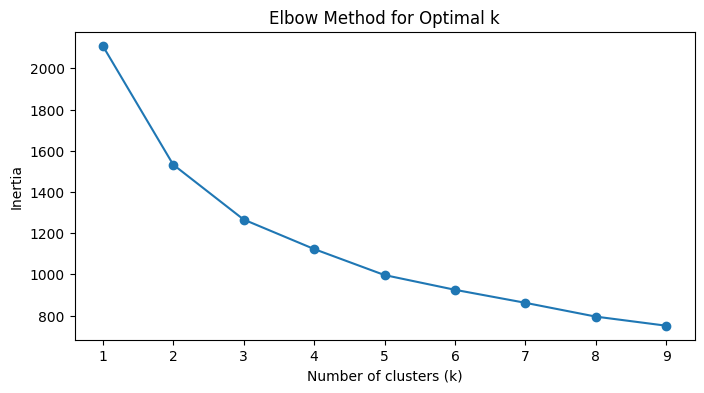

In [23]:
features = ['Total_Accidents', 'Avg_Casualties', 'Avg_Vehicles', 'Pct_Serious_Fatal', 'Pct_Urban']
X = cluster_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method to pick k
inertias = []
k_range = range(1, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(k_range, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [24]:
# k=4 chosen — clear elbow bend, and gives interpretable cluster granularity
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = cluster_df.groupby('Cluster')[features].mean().round(2)
cluster_profile['District_Count'] = cluster_df['Cluster'].value_counts().sort_index()

display(cluster_profile)

,Total_Accidents,Avg_Casualties,Avg_Vehicles,Pct_Serious_Fatal,Pct_Urban,District_Count
Cluster,,,,,,
0,565.27,1.29,1.84,0.13,0.77,119
1,657.25,1.43,1.87,0.14,0.43,161
2,441.25,1.42,1.73,0.21,0.20,92
3,1885.88,1.27,1.80,0.12,0.94,50


**Cluster interpretation:**
- **Cluster 3 — High-volume urban hubs** (50 districts, 94% urban): highest raw accident counts, but lowest severity rate. Dense traffic means more accidents, but slower speeds mean fewer are severe.
- **Cluster 1 — Moderate mixed districts** (161 districts): middle-of-the-road on all metrics, largest group.
- **Cluster 0 — Lower-volume urban-leaning** (119 districts, 77% urban): similar severity to Cluster 3, far fewer accidents.
- **Cluster 2 — Low-volume rural, high severity** (92 districts, 20% urban): fewest accidents overall, but the highest severity rate (21%, some districts over 30%).

**Key finding:** rural districts see accidents far less often, but when they happen, they're disproportionately serious or fatal — likely a mix of higher speed limits, longer emergency response times, and less traffic to force lower speeds.

In [26]:
# Districts in the highest-severity cluster
worst_cluster = cluster_profile['Pct_Serious_Fatal'].idxmax()
print(f"Cluster {worst_cluster} has the highest serious/fatal rate")
display(cluster_df[cluster_df['Cluster'] == worst_cluster][['Local_Authority_(District)', 'Pct_Serious_Fatal', 'Total_Accidents']].sort_values('Pct_Serious_Fatal', ascending=False).head(10))

Cluster 2 has the highest serious/fatal rate


,Local_Authority_(District),Pct_Serious_Fatal,Total_Accidents
292,Ryedale,0.337243,341
1,Aberdeenshire,0.298399,687
281,Richmondshire,0.296178,314
108,Dumfries and Galloway,0.291237,388
323,South Northamptonshire,0.288136,413
206,Maldon,0.277551,245
92,Craven,0.273713,369
100,Daventry,0.265823,395
181,Isle of Anglesey,0.264368,261
375,Tynedale,0.257143,35


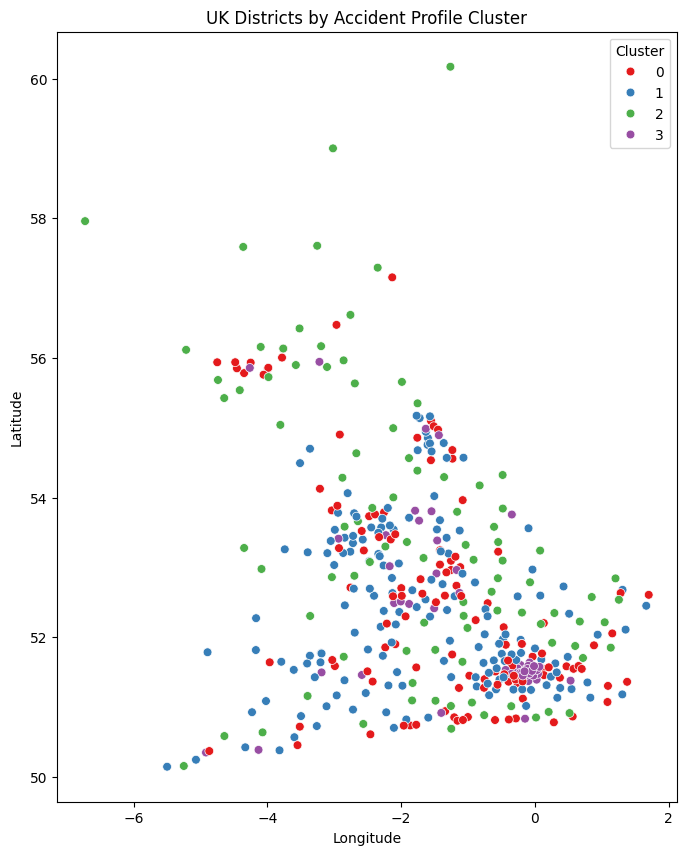

In [27]:
# Map of districts by cluster
geo = df.groupby('Local_Authority_(District)')[['Latitude', 'Longitude']].mean().reset_index()
cluster_geo = cluster_df.merge(geo, on='Local_Authority_(District)')

plt.figure(figsize=(8,10))
sns.scatterplot(data=cluster_geo, x='Longitude', y='Latitude', hue='Cluster', palette='Set1', s=40)
plt.title("UK Districts by Accident Profile Cluster")
plt.show()

## Conclusion

- **Timing & lighting:** accident frequency peaks during commuting hours; darkness conditions show a shifted severity profile compared to daylight.
- **Junctions:** certain junction types and control setups carry disproportionately higher severity shares.
- **Association rules:** specific combinations of weather, lighting, and junction control co-occur with higher-severity accidents at rates above chance (lift > 1.2).
- **Forecasting:** short-term trend structure is statistically detectable, but 24 months of data isn't enough for a reliable seasonal forecast — treat projections as indicative.
- **Clustering:** the clearest and most actionable finding — low-traffic rural districts have disproportionately higher severity rates than high-traffic urban ones, despite fewer total accidents.